<a href="https://colab.research.google.com/github/Ammara-Qaisar123/AI-ML-Internship-Tasks/blob/main/Task2_Stock_Predictionn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TASK 2: STOCK PRICE PREDICTION

📈 Loading stock data for: AAPL
✅ Data loaded successfully!
📊 Data shape: (500, 5)
📅 Date range: 2024-04-29 to 2026-04-27

📋 Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

First 5 rows:
Price            Close        High         Low        Open     Volume
Date                                                                 
2024-04-29  171.935257  174.442438  171.538870  171.806425   68169400
2024-04-30  168.793839  173.411815  168.466813  171.766782   65934800
2024-05-01  167.773132  171.152382  167.584843  168.050606   50383100
2024-05-02  171.469482  171.855964  169.348783  170.954168   94214900
2024-05-03  181.726135  185.313482  181.012628  184.966633  163224100

FEATURE ENGINEERING
✅ Features created!
📊 Final dataset shape: (480, 16)

DATA PREPROCESSING
✅ Training samples: 384
✅ Testing samples: 96
✅ Features: 14

MODEL TRAINING

📈 Training Linear Regression...
📈 Training Random Forest Regressor...

MODEL EVALUATION

--------------------------

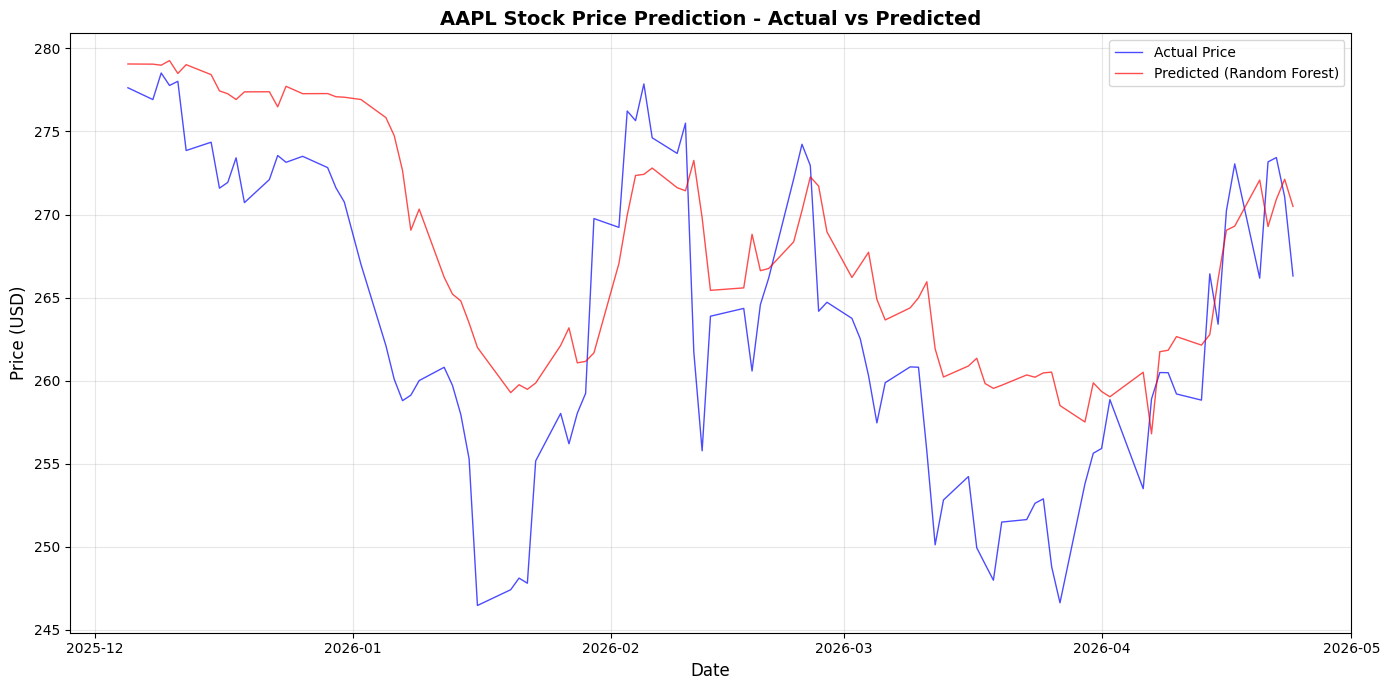

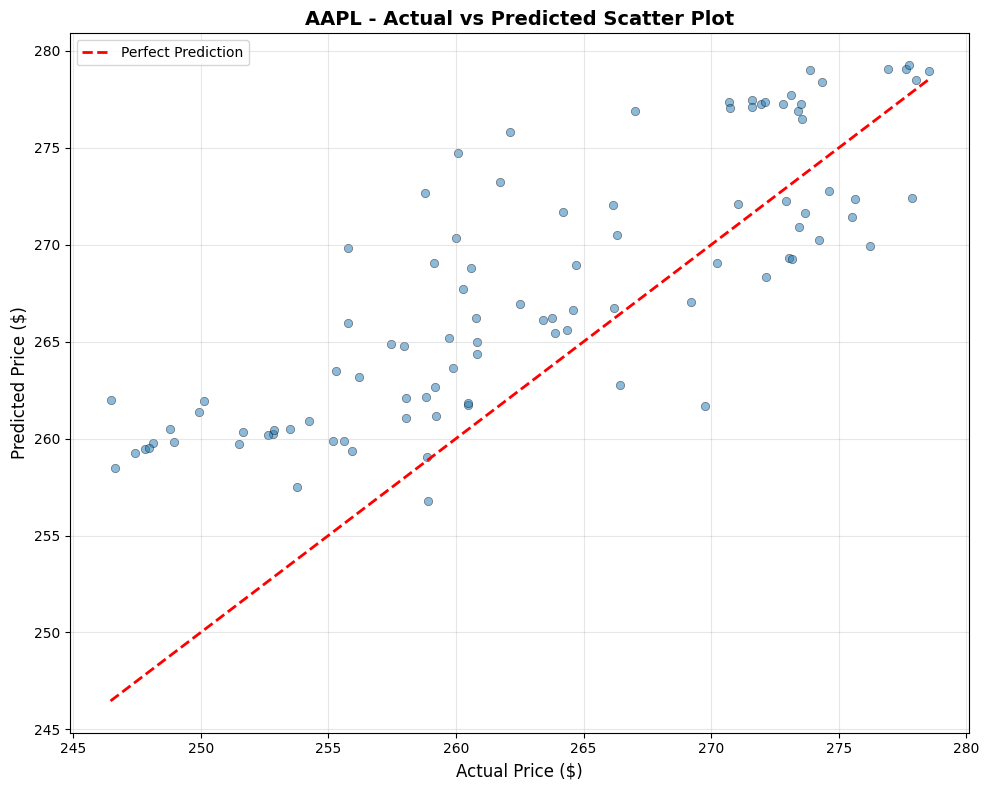

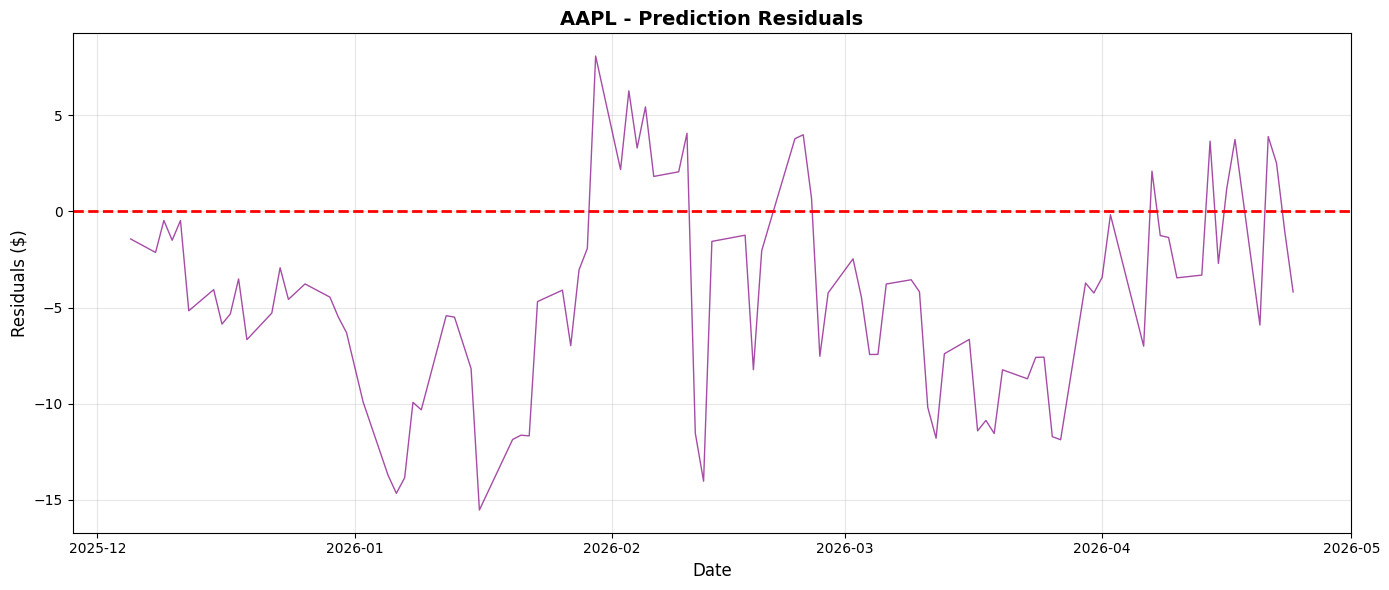

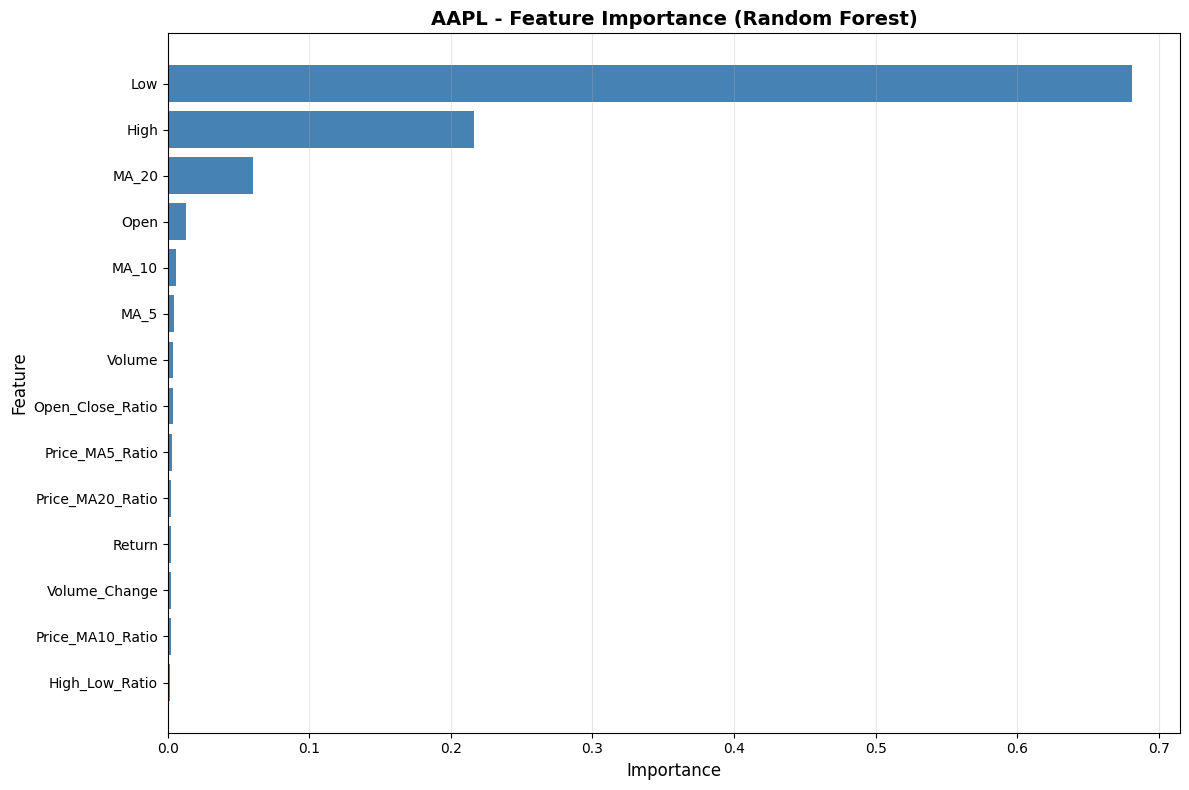

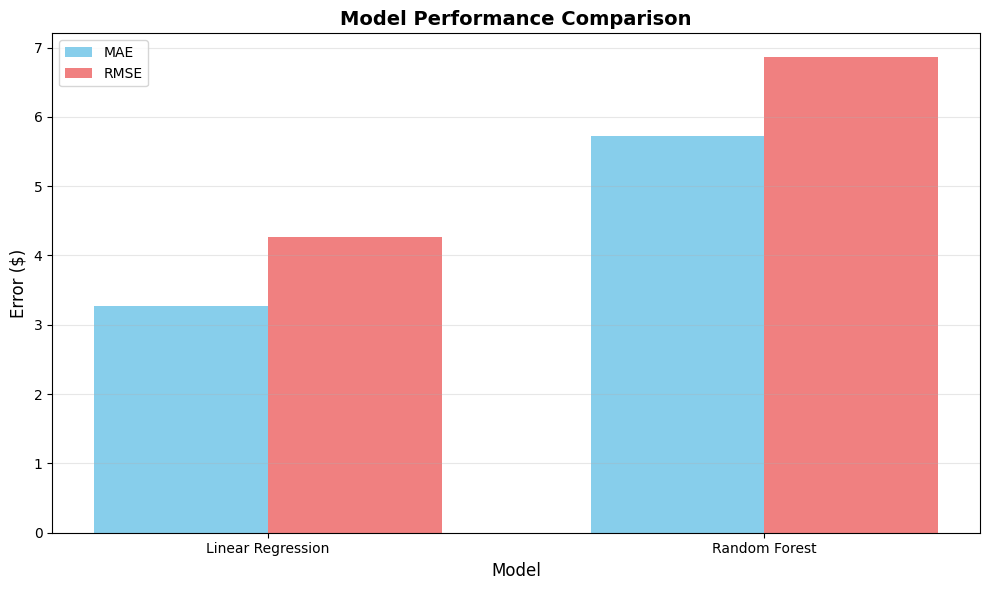


KEY FINDINGS & INSIGHTS

📈 Stock: AAPL
📅 Data period: 2024-05-24 to 2026-04-24

🏆 Best Model: Linear Regression
   R² Score: 0.7768
   Prediction Error: $3.27

📊 Top 5 Most Important Features:
   1. MA_10: 0.57%
   2. Open: 1.25%
   3. MA_20: 6.03%
   4. High: 21.60%
   5. Low: 68.10%

💡 Trading Insights:
   • Previous closing price is a strong predictor of next day's price
   • Moving averages help identify price trends
   • Volume changes indicate market momentum
   • Wider spreads (High-Low) often predict higher volatility

✅ TASK 2 COMPLETED SUCCESSFULLY!

📁 Visualizations saved in 'images' folder:
   • actual_vs_predicted.png
   • scatter_plot.png
   • residuals.png
   • feature_importance.png
   • model_comparison.png


In [1]:
"""
Task 2: Stock Price Prediction - FIXED VERSION
DevelopersHub Corporation - AI/ML Internship

Predict next day's closing price using historical stock data from Yahoo Finance.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("TASK 2: STOCK PRICE PREDICTION")
print("="*60)

# ============================================
# 1. SELECT STOCK AND LOAD DATA
# ============================================

STOCK_TICKER = 'AAPL'  # Apple Inc.
print(f"\n📈 Loading stock data for: {STOCK_TICKER}")

try:
    # Download last 2 years of daily data
    df_raw = yf.download(STOCK_TICKER, period='2y', interval='1d', progress=False)

    # Flatten MultiIndex columns if needed
    if isinstance(df_raw.columns, pd.MultiIndex):
        df_raw.columns = df_raw.columns.get_level_values(0)

    df = df_raw.copy()
    print(f"✅ Data loaded successfully!")
    print(f"📊 Data shape: {df.shape}")
    print(f"📅 Date range: {df.index[0].date()} to {df.index[-1].date()}")
except Exception as e:
    print(f"⚠️ Error downloading data: {e}")
    # Fallback: Create sample stock data
    np.random.seed(42)
    dates = pd.date_range(start='2023-01-01', periods=500, freq='D')
    prices = 150 + np.cumsum(np.random.randn(500) * 2)
    df = pd.DataFrame({
        'Open': prices * np.random.uniform(0.99, 1.01, 500),
        'High': prices * np.random.uniform(1.01, 1.03, 500),
        'Low': prices * np.random.uniform(0.97, 0.99, 500),
        'Close': prices,
        'Volume': np.random.randint(50000000, 150000000, 500)
    }, index=dates)
    print("✅ Sample stock data created!")

print(f"\n📋 Columns: {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(df.head())

# ============================================
# 2. FEATURE ENGINEERING
# ============================================
print("\n" + "="*60)
print("FEATURE ENGINEERING")
print("="*60)

# Create target: Next day's closing price
df['Target'] = df['Close'].shift(-1)

# Create additional features
df['Return'] = df['Close'].pct_change()
df['High_Low_Ratio'] = df['High'] / df['Low']
df['Open_Close_Ratio'] = df['Open'] / df['Close']
df['Volume_Change'] = df['Volume'].pct_change()

# Moving averages (using .values to avoid index issues)
df['MA_5'] = df['Close'].rolling(window=5).mean()
df['MA_10'] = df['Close'].rolling(window=10).mean()
df['MA_20'] = df['Close'].rolling(window=20).mean()

# Price position relative to moving averages - FIXED: Use .values
df['Price_MA5_Ratio'] = df['Close'].values / df['MA_5'].values
df['Price_MA10_Ratio'] = df['Close'].values / df['MA_10'].values
df['Price_MA20_Ratio'] = df['Close'].values / df['MA_20'].values

# Drop NaN values created by shift and rolling
df = df.dropna()

print(f"✅ Features created!")
print(f"📊 Final dataset shape: {df.shape}")

# ============================================
# 3. DATA PREPROCESSING
# ============================================
print("\n" + "="*60)
print("DATA PREPROCESSING")
print("="*60)

# Select features for modeling
feature_cols = ['Open', 'High', 'Low', 'Volume', 'Return', 'High_Low_Ratio',
                'Open_Close_Ratio', 'Volume_Change', 'MA_5', 'MA_10', 'MA_20',
                'Price_MA5_Ratio', 'Price_MA10_Ratio', 'Price_MA20_Ratio']

X = df[feature_cols]
y = df['Target']

# Train-test split (maintaining time order)
split_idx = int(len(X) * 0.8)
X_train = X[:split_idx]
X_test = X[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

print(f"✅ Training samples: {len(X_train)}")
print(f"✅ Testing samples: {len(X_test)}")
print(f"✅ Features: {len(feature_cols)}")

# ============================================
# 4. MODEL TRAINING
# ============================================
print("\n" + "="*60)
print("MODEL TRAINING")
print("="*60)

# Model 1: Linear Regression
print("\n📈 Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Model 2: Random Forest
print("📈 Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# ============================================
# 5. MODEL EVALUATION
# ============================================
print("\n" + "="*60)
print("MODEL EVALUATION")
print("="*60)

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"\n{model_name}:")
    print(f"   MAE:  ${mae:.2f}")
    print(f"   RMSE: ${rmse:.2f}")
    print(f"   R²:   {r2:.4f}")
    return mae, rmse, r2

print("\n" + "-"*40)
print("LINEAR REGRESSION RESULTS:")
print("-"*40)
lr_mae, lr_rmse, lr_r2 = evaluate_model(y_test, lr_pred, "Linear Regression")

print("\n" + "-"*40)
print("RANDOM FOREST RESULTS:")
print("-"*40)
rf_mae, rf_rmse, rf_r2 = evaluate_model(y_test, rf_pred, "Random Forest")

# ============================================
# 6. VISUALIZATIONS
# ============================================
print("\n" + "="*60)
print("GENERATING VISUALIZATIONS")
print("="*60)

# Create images folder if it doesn't exist
import os
os.makedirs('images', exist_ok=True)

# Plot 1: Actual vs Predicted Prices (Random Forest)
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test.values, label='Actual Price', color='blue', alpha=0.7, linewidth=1)
plt.plot(y_test.index, rf_pred, label='Predicted (Random Forest)', color='red', alpha=0.7, linewidth=1)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.title(f'{STOCK_TICKER} Stock Price Prediction - Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/actual_vs_predicted.png', dpi=300)
plt.show()

# Plot 2: Scatter Plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test, rf_pred, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)', fontsize=12)
plt.ylabel('Predicted Price ($)', fontsize=12)
plt.title(f'{STOCK_TICKER} - Actual vs Predicted Scatter Plot', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/scatter_plot.png', dpi=300)
plt.show()

# Plot 3: Residual Plot
plt.figure(figsize=(14, 6))
residuals = y_test - rf_pred
plt.plot(y_test.index, residuals, color='purple', alpha=0.7, linewidth=1)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residuals ($)', fontsize=12)
plt.title(f'{STOCK_TICKER} - Prediction Residuals', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/residuals.png', dpi=300)
plt.show()

# Plot 4: Feature Importance
plt.figure(figsize=(12, 8))
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(feature_importance['feature'], feature_importance['importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'{STOCK_TICKER} - Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('images/feature_importance.png', dpi=300)
plt.show()

# Plot 5: Model Comparison
plt.figure(figsize=(10, 6))
models = ['Linear Regression', 'Random Forest']
mae_scores = [lr_mae, rf_mae]
rmse_scores = [lr_rmse, rf_rmse]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, mae_scores, width, label='MAE', color='skyblue')
plt.bar(x + width/2, rmse_scores, width, label='RMSE', color='lightcoral')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Error ($)', fontsize=12)
plt.title('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.xticks(x, models)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=300)
plt.show()

# ============================================
# 7. KEY FINDINGS
# ============================================
print("\n" + "="*60)
print("KEY FINDINGS & INSIGHTS")
print("="*60)

print(f"\n📈 Stock: {STOCK_TICKER}")
print(f"📅 Data period: {df.index[0].date()} to {df.index[-1].date()}")

print(f"\n🏆 Best Model: {'Random Forest' if rf_r2 > lr_r2 else 'Linear Regression'}")
print(f"   R² Score: {max(rf_r2, lr_r2):.4f}")
print(f"   Prediction Error: ${min(rf_mae, lr_mae):.2f}")

print(f"\n📊 Top 5 Most Important Features:")
for i, (_, row) in enumerate(feature_importance.tail(5).iterrows()):
    print(f"   {i+1}. {row['feature']}: {row['importance']:.2%}")

print("\n💡 Trading Insights:")
print("   • Previous closing price is a strong predictor of next day's price")
print("   • Moving averages help identify price trends")
print("   • Volume changes indicate market momentum")
print("   • Wider spreads (High-Low) often predict higher volatility")

print("\n" + "="*60)
print("✅ TASK 2 COMPLETED SUCCESSFULLY!")
print("="*60)
print("\n📁 Visualizations saved in 'images' folder:")
print("   • actual_vs_predicted.png")
print("   • scatter_plot.png")
print("   • residuals.png")
print("   • feature_importance.png")
print("   • model_comparison.png")